# 01 — The `Leaf`, in pictures

Hands-on companion to [`docs/01-leaf.md`](../docs/01-leaf.md).

> Run this with the notebook extra installed: `pip install -e ".[notebooks]"`

In [1]:
import matplotlib.pyplot as plt
from bonsaigrad import Leaf

In [2]:
# Collect all nodes and edges (parent -> child) reachable from root.
def _trace(root):
    nodes, edges, seen = [], [], set()

    def walk(n):
        if id(n) in seen:
            return
        seen.add(id(n))
        nodes.append(n)
        for p in n._prev:
            edges.append((p, n))
            walk(p)

    walk(root)
    return nodes, edges


# Longest path from a root: roots sit at 0, the output highest.
def _depth(node, memo):
    if id(node) in memo:
        return memo[id(node)]
    d = 0 if not node._prev else 1 + max(_depth(p, memo) for p in node._prev)
    memo[id(node)] = d
    return d


# Draw the graph: nodes by depth, arrows for edges, each box showing op/data/grad.
def draw_graph(root, names=None, ax=None, title=None):
    names = names or {}
    nodes, edges = _trace(root)

    memo, levels = {}, {}
    for n in nodes:
        levels.setdefault(_depth(n, memo), []).append(n)

    pos = {}
    for d, layer in levels.items():
        for i, n in enumerate(layer):
            pos[id(n)] = (i - (len(layer) - 1) / 2, d)  # center each layer

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    for p, ch in edges:
        (x0, y0), (x1, y1) = pos[id(p)], pos[id(ch)]
        ax.annotate("", xy=(x1, y1 - 0.28), xytext=(x0, y0 + 0.28),
                    arrowprops=dict(arrowstyle="-|>", color="#8a8a8a", lw=1.4))

    for n in nodes:
        x, y = pos[id(n)]
        label = names.get(id(n)) or (n._op if n._op else "leaf")
        flowed = float(n.grad) != 0.0
        color = "#cde8d1" if flowed else "#e8e8e8"
        ax.text(x, y, f"{label}\ndata {n.data.item():.4g}\ngrad {n.grad.item():.4g}",
                ha="center", va="center", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.4", fc=color, ec="#4a4a4a", lw=1.2))

    xs = [p[0] for p in pos.values()]
    ax.set_xlim(min(xs) - 0.8, max(xs) + 0.8)
    ax.set_ylim(-0.6, max(levels) + 0.6)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11)
    return ax

## An expression grows a graph

Writing `f = a * b + a` does not just compute a number — every `*` and `+` creates a new `Leaf` that remembers its parents.

f = 15.0


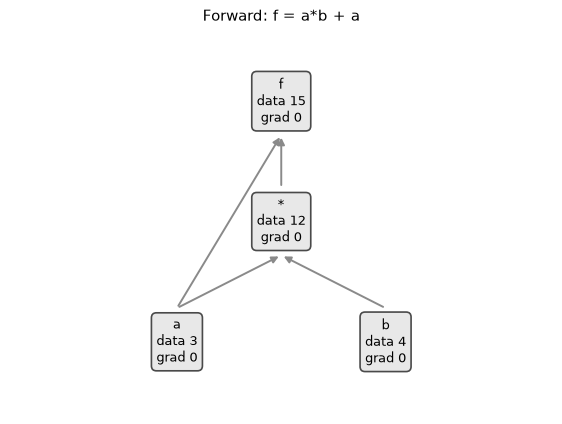

In [3]:
a = Leaf(3.0)
b = Leaf(4.0)
f = a * b + a
names = {id(a): "a", id(b): "b", id(f): "f"}

print("f =", f.data.item())
draw_graph(f, names, title="Forward: f = a*b + a")
plt.show()

## The backward pass: `bend`

`bend` seeds the top with `1` and walks the tree in reverse, letting each node
hand its gradient to its parents. After it runs, every node knows its gradient
(the boxes turn green).

By hand: `f = a·b + a`, so `∂f/∂a = b + 1 = 5` and `∂f/∂b = a = 3`. Note how the
two paths into `a` (through the product, and directly) **add up** — that is the
`+=` in the backward rules.

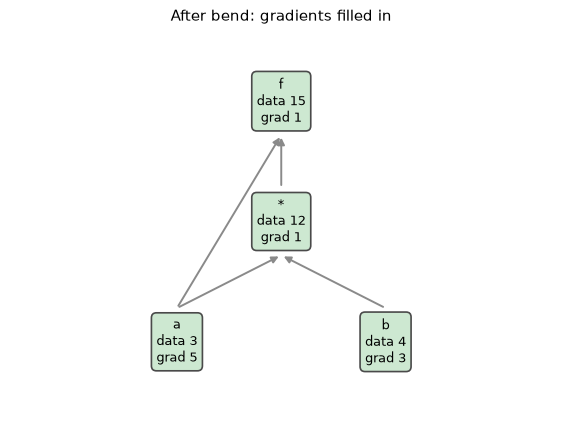

a.grad = 5.0 (expected 5.0)
b.grad = 3.0 (expected 3.0)


In [4]:
f.bend()
draw_graph(f, names, title="After bend: gradients filled in")
plt.show()

print("a.grad =", a.grad.item(), "(expected 5.0)")
print("b.grad =", b.grad.item(), "(expected 3.0)")
assert a.grad.item() == 5.0 and b.grad.item() == 3.0

## A tiny neuron

The same machinery already gives us a single neuron: `y = w * x + b`. Weight `w`,
input `x`, bias `b`. Below, the graph before and after `bend`, side by side.

By hand, `∂y/∂w = x`, `∂y/∂x = w`, `∂y/∂b = 1` — read them straight off the green
boxes on the right.

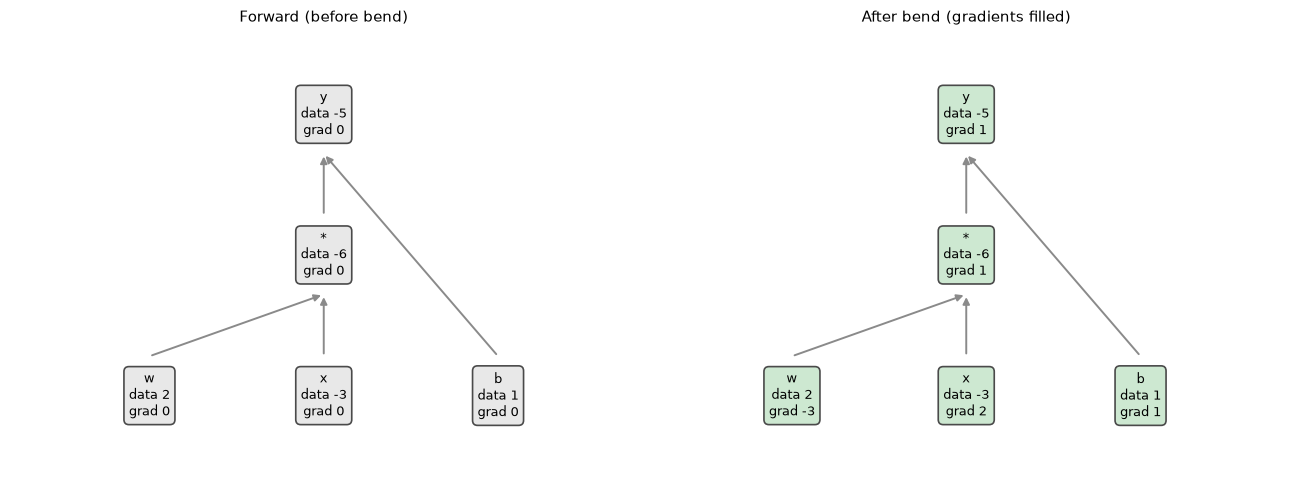

y = -5.0  |  w.grad = -3.0  x.grad = 2.0  b.grad = 1.0


In [5]:
w, x, b = Leaf(2.0), Leaf(-3.0), Leaf(1.0)
y = w * x + b
names = {id(w): "w", id(x): "x", id(b): "b", id(y): "y"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
draw_graph(y, names, ax=ax1, title="Forward (before bend)")
y.bend()
draw_graph(y, names, ax=ax2, title="After bend (gradients filled)")
plt.tight_layout()
plt.show()

print(f"y = {y.data.item()}  |  w.grad = {w.grad.item()}  x.grad = {x.grad.item()}  b.grad = {b.grad.item()}")

## Putting it together

One larger expression, still built from nothing but `+` and `*`:

`L = (a + b) * c + (d + e) * f + g`

Seven inputs, several layers deep. `bend` fills in every gradient in a single pass — and each one matches the partial derivative by hand (e.g. `∂L/∂c = a + b`, `∂L/∂f = d + e`, `∂L/∂g = 1`).

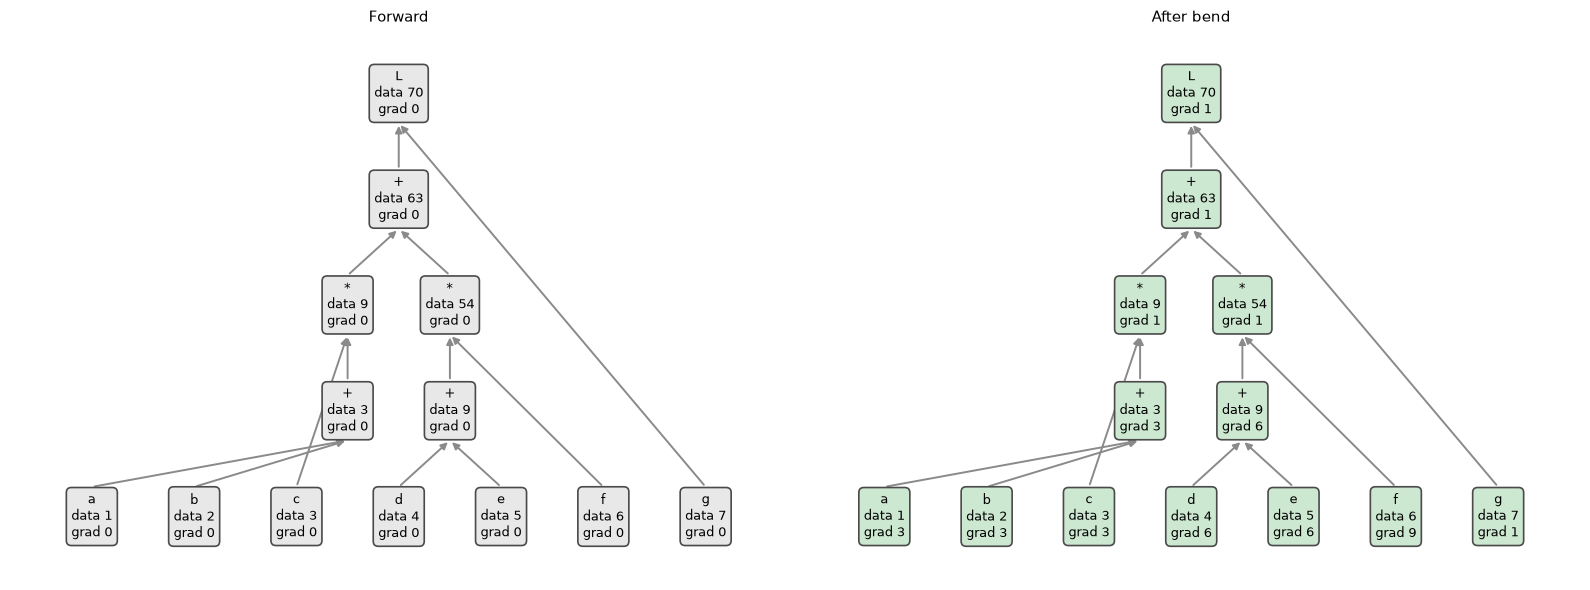

a.grad = 3
b.grad = 3
c.grad = 3
d.grad = 6
e.grad = 6
f.grad = 9
g.grad = 1


In [6]:
a, b, c, d, e, f, g = (Leaf(v) for v in (1, 2, 3, 4, 5, 6, 7))
L = (a + b) * c + (d + e) * f + g
names = {id(a): "a", id(b): "b", id(c): "c", id(d): "d",
         id(e): "e", id(f): "f", id(g): "g", id(L): "L"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
draw_graph(L, names, ax=ax1, title="Forward")
L.bend()
draw_graph(L, names, ax=ax2, title="After bend")
plt.tight_layout()
plt.show()

for name, leaf in zip("abcdefg", (a, b, c, d, e, f, g)):
    print(f"{name}.grad = {leaf.grad.item():.0f}")

## What the picture shows

- The graph is **built by the forward pass** — every operation leaves a node.
- `bend` flows gradients **top to bottom**, and each green box is a `∂output/∂node`.
- A reused node (like `a`) collects gradient from **every path** it feeds.

That is the whole autograd engine.